In [ ]:
import numpy as np
X = np.array(([2, 9], [1, 5], [3, 6]), dtype=float)
y = np.array(([92], [86], [89]), dtype=float)
X = X/np.amax(X,axis=0)
y = y/100

def sigmoid(x):
    return 1/(1 + np.exp(-x))

def derivatives_sigmoid(x):
    return x * (1 - x)

epoch = 5
lr = 0.1
inputlayer_neurons = 2
hiddenlayer_neurons = 3
output_neurons = 1

wh = np.random.uniform(size=(inputlayer_neurons,hiddenlayer_neurons))
bh = np.random.uniform(size=(1,hiddenlayer_neurons))
wout = np.random.uniform(size=(hiddenlayer_neurons,output_neurons))
bout = np.random.uniform(size=(1,output_neurons))

for i in range(epoch):
    # Forward Propagation
    hinp1 = np.dot(X, wh)
    hinp = hinp1 + bh
    hlayer_act = sigmoid(hinp)
    outinp1 = np.dot(hlayer_act, wout)
    outinp = outinp1 + bout
    output = sigmoid(outinp)

    # Backpropagation
    EO = y - output
    outgrad = derivatives_sigmoid(output)
    d_output = EO * outgrad
    EH = d_output.dot(wout.T)
    hiddengrad = derivatives_sigmoid(hlayer_act)
    d_hiddenlayer = EH * hiddengrad

    wout += hlayer_act.T.dot(d_output) * lr
    wh += X.T.dot(d_hiddenlayer) * lr

    print("Epoch-", i+1)
    print("Predicted Output:\n", output)

print("Final Predicted Output:\n", output)

Epoch- 1
Predicted Output:
 [[0.91396269]
 [0.90174502]
 [0.91563658]]
Epoch- 2
Predicted Output:
 [[0.91388526]
 [0.90166597]
 [0.91555976]]
Epoch- 3
Predicted Output:
 [[0.913808 ]
 [0.9015871]
 [0.9154831]]
Epoch- 4
Predicted Output:
 [[0.91373092]
 [0.90150842]
 [0.91540662]]
Epoch- 5
Predicted Output:
 [[0.91365401]
 [0.90142993]
 [0.91533032]]
Final Predicted Output:
 [[0.91365401]
 [0.90142993]
 [0.91533032]]


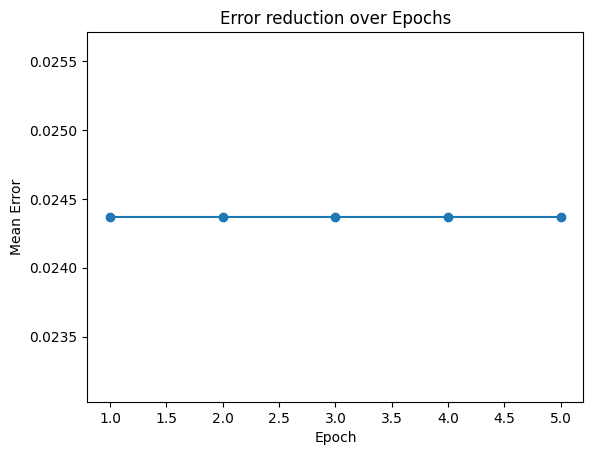

In [ ]:
import matplotlib.pyplot as plt

errors = []
for i in range(epoch):
    # ... existing forward + backward code ...
    errors.append(np.mean(np.abs(EO)))

plt.plot(range(1, epoch+1), errors, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Error')
plt.title('Error reduction over Epochs')
plt.show()